**PROJECT-BASED INTERNSHIP VINIX7**

**Modul 5: Pengantar Machine Learning**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('tokopedia_product_reviews_2025.csv')
print(df.head())
print("\n")
df.info()

                                         review_text review_date   review_id  \
0  baru sekali ini terima brg dr belanja online d...  2024-12-22  1134256160   
1  cocok bgt aku sama telur nya. nga Amis menurut...  2025-02-25  1242584634   
2  Telornya sudah sampai di rumah dengan kemasan ...  2025-07-15  1573444677   
3  Telor sudah diterima dengan baik dan tidak ada...  2025-07-20  1581728541   
4  Alhamdulillah penjual amanah,Telor nya terbaik...  2023-04-24   881041355   

                                        product_name   product_category  \
0  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
1  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
2  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
3  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
4  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   

   product_variant  product_price  \
0        Box Polos          870

In [ ]:
# Tahap 1: Data Splitting
X= df['review_text']
y= df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

print('X_train: ')
print(X_train.head())
print("X_train shape:", X_train.shape)
print('\n')

print('X_test: ')
print(X_test.head())
print("X_test shape:", X_test.shape)
print('\n')

print('y_train: ')
print(y_train.head())
print("y_train shape:", y_train.shape)
print('\n')

print('y_test: ')
print(y_test.head())
print("y_test shape:", y_test.shape)

X_train: 
47354    barang ori dan berfungsi dengan baik untuk coo...
42142                                                Mantp
60422                                            Mantapppp
60981    Ukuran cukup, bahan &amp; material bagus, sesu...
11385            enak. pekat. coklatnya ori. lumayan pahit
Name: review_text, dtype: object
X_train shape: (52434,)


X_test: 
8383     Kemasannya exclusive bgttt, pengiriman cepat, ...
31405    Kipas kecil² tp cabe rawit, keren bnget krn ra...
51316                      Bagus..langsung pakai, mantabbb
1295     Sayur &amp; lauk semua fresh, respon cepat dan...
16817                                                 Good
Name: review_text, dtype: object
X_test shape: (13109,)


y_train: 
47354    positive
42142    positive
60422    positive
60981    positive
11385    positive
Name: sentiment_label, dtype: object
y_train shape: (52434,)


y_test: 
8383     positive
31405    positive
51316    positive
1295     positive
16817    positive
Name: sentim

**Interpretasi 1**

Pemisahan data menjadi Training Set dan Testing Set wajib dilakukan untuk mengevaluasi performa dan kemampuan generalisasi model secara objektif pada data baru. Jika model divalidasi menggunakan data yang sama dengan data pelatihan, akan terjadi kebocoran data (data leakage). Model akan memunculkan metrik performa semu yang tinggi akibat sekadar menghafal data, namun akan gagal total saat menghadapi data riil di tahap produksi.

In [ ]:
df_pred = pd.read_csv('dummy_model_predictions.csv')
print(df_pred.head())
print("\n")
df_pred.info()

     review_id actual_sentiment pred_alpha pred_beta pred_gamma
0  REV-TX-1000         positive   positive  negative   positive
1  REV-TX-1001         negative   positive  negative   negative
2  REV-TX-1002         positive   negative  negative   positive
3  REV-TX-1003         positive   positive  positive   positive
4  REV-TX-1004         positive   positive  positive   positive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         2000 non-null   object
 1   actual_sentiment  2000 non-null   object
 2   pred_alpha        2000 non-null   object
 3   pred_beta         2000 non-null   object
 4   pred_gamma        2000 non-null   object
dtypes: object(5)
memory usage: 78.3+ KB


**Interpretasi 2**

Porsi data aktual berstatus imbalanced (tidak seimbang) secara ekstrem akibat majority class dominance, dengan 1.695 ulasan positif berbanding hanya 305 ulasan negatif. Metrik Accuracy menipu pada kondisi ini karena menjadi tolok ukur yang bias. Sebagai baseline, jika model secara buta memprediksi semua ulasan sebagai kelas positif, akurasinya sudah mencapai ~84,75% (1.695/2.000). Model Alpha mendapat akurasi 78% hanya dengan berpihak pada kelas mayoritas, namun terbukti gagal mendeteksi kelas minoritas.

Confusion Matrix Model Alpha:
 [[  31  274]
 [ 162 1533]] 



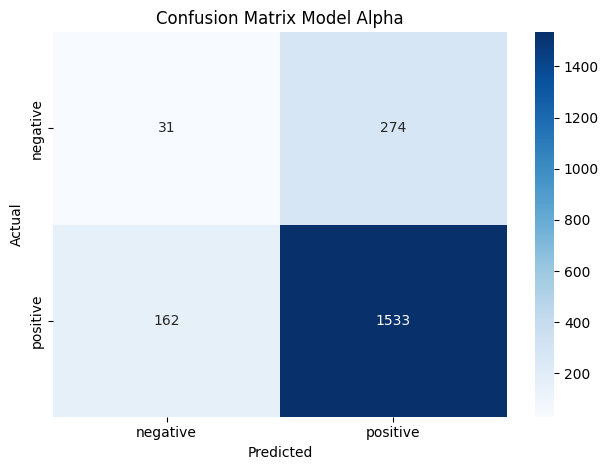


Classification Report Model Alpha:
               precision    recall  f1-score   support

    negative       0.16      0.10      0.12       305
    positive       0.85      0.90      0.88      1695

    accuracy                           0.78      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.74      0.78      0.76      2000



In [ ]:
# Model Alpha
y_true = df_pred['actual_sentiment']
y_pred_alpha = df_pred['pred_alpha']

conf_matrix_alpha = confusion_matrix(y_true, y_pred_alpha, labels=["negative", "positive"])
print("Confusion Matrix Model Alpha:\n", conf_matrix_alpha, "\n")

sns.heatmap(conf_matrix_alpha, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Model Alpha")
plt.tight_layout()
plt.show()

report_alpha = classification_report(y_true, y_pred_alpha, labels=["negative", "positive"], target_names=["negative", "positive"])
print("\nClassification Report Model Alpha:\n", report_alpha)

**Interpretasi 3**

Berdasarkan Confusion Matrix Model Alpha, terdapat 274 kasus kebocoran komplain. Secara istilah klasifikasi, ini adalah False Negative (data aktual negatif/komplain, namun diprediksi positif/ulasan baik). Dalam studi kasus ini, metrik yang paling wajib dioptimalkan adalah Recall untuk kelas negatif dibandingkan Precision. Secara bisnis, melewatkan komplain asli (False Negative) berisiko fatal karena keluhan tidak akan ditangani oleh Customer Service, sedangkan salah mendeteksi ulasan baik sebagai komplain (False Positive) hanya berdampak pada pengecekan manual ekstra.

In [ ]:
# Model Beta
y_true = df_pred['actual_sentiment']
y_pred_beta = df_pred['pred_beta']

report_beta = classification_report(y_true, y_pred_beta, labels=["negative", "positive"], target_names=["negative", "positive"])
print("\nClassification Report Model Beta:\n", report_beta)

# Model Gamma
y_true = df_pred['actual_sentiment']
y_pred_gamma = df_pred['pred_gamma']

report_gamma = classification_report(y_true, y_pred_gamma, labels=["negative", "positive"], target_names=["negative", "positive"])
print("\nClassification Report Model Gamma:\n", report_gamma)


Classification Report Model Beta:
               precision    recall  f1-score   support

    negative       0.16      0.46      0.23       305
    positive       0.85      0.55      0.67      1695

    accuracy                           0.54      2000
   macro avg       0.50      0.51      0.45      2000
weighted avg       0.75      0.54      0.61      2000


Classification Report Model Gamma:
               precision    recall  f1-score   support

    negative       0.65      0.83      0.73       305
    positive       0.97      0.92      0.94      1695

    accuracy                           0.91      2000
   macro avg       0.81      0.87      0.84      2000
weighted avg       0.92      0.91      0.91      2000



**Interpretasi 4**

*   **Model Alpha (Overfitting)**: Training Accuracy 99% berbanding Testing Accuracy 78%. Selisih signifikan ini membuktikan fenomena High Variance. model terlalu kompleks sehingga menghafal noise pada data latih namun gagal menggeneralisasi data uji.
*   **Model Beta (Underfitting):** Training Accuracy 55% berbanding Testing Accuracy 54%. Skor yang sangat rendah di kedua fase menunjukkan fenomena High Bias. model terlalu sederhana dan terbukti gagal memodelkan pola dasar dari data.
*   **Model Gamma (Ideal Fit):** Training Accuracy 92% berbanding Testing Accuracy 91%. Skor tinggi dan konsisten ini membuktikan model berhasil menyeimbangkan bias dan varians (Low Bias, Low Variance) serta mampu memprediksi data baru dengan optimal.



**Interpretasi 5 — Kesimpulan Akhir**

Berdasarkan seluruh analisis yang telah dilakukan, **Model Gamma** adalah kandidat paling layak untuk di-deploy ke tahap produksi. Dari sisi kesehatan model, Gamma menunjukkan kondisi *ideal fit* dengan Training Accuracy 92% dan Testing Accuracy 91% yang sangat konsisten, jauh lebih sehat dibanding Alpha yang *overfitting* (99% vs 78%) maupun Beta yang *underfitting* (55% vs 54%). Dari sisi kemampuan mendeteksi komplain, Gamma juga unggul dengan Recall kelas negatif sebesar 83%, artinya dari setiap 100 ulasan komplain asli, 83 di antaranya berhasil terdeteksi dengan benar — jauh lebih baik dibanding Alpha (10%) maupun Beta (46%). Meskipun Model Beta memiliki Recall negatif yang lebih tinggi dari Alpha, akurasi keseluruhannya yang hanya 54% menandakan model ini tidak cukup andal secara umum, sehingga Model Gamma tetap menjadi pilihan terbaik yang mampu menyeimbangkan performa menyeluruh sekaligus meminimalkan risiko komplain pelanggan yang terlewat oleh tim Customer Service.
